<a href="https://colab.research.google.com/github/Akanshajoshiiii/SpeechLAB/blob/main/Copy_of_LAB3_HMM_Modelling_using_Traffic_Congestion_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this problem, we have created a synthetic dataset with columns number of vehicles passing at a crossing per hour and label as congestion/non congestion. We need to design the above problem as markov chain with initial probabilities being caluclated as (states are {Congestion, No congestion})Number of congested events/ Total number of events. Transition probabilities being calculated using exponential distribution with mean as time required for congested event to become non-congested and vice-versa. Observation probabilities as gaussian mixture models.

Dataset Description
| Column              | Meaning                                                 |
| ------------------- | ------------------------------------------------------- |
| `vehicles_per_hour` | Number of vehicles crossing an intersection in one hour |
| `label`             | `{Congestion, Non-congestion}`                          |


Why HMM?

Traffic state evolves over time
Current traffic condition depends mainly on previous condition
Congestion state is not directly observable
What we observe is vehicle count
| Component           | Meaning                     |
| ------------------- | --------------------------- |
| Hidden state        | Congestion / Non-congestion |
| Observation         | Vehicles per hour           |
| Temporal dependency | Markov assumption           |


In [ ]:
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

Synthetic Data Generation

In [ ]:
np.random.seed(42) #Every run gives same data

n_hours = 500

# Hidden states
states = ["Congestion", "Non-Congestion"]

# Vehicle distributions
# Congestion → high counts
# Non-congestion → low counts

congestion_dist = np.random.normal(180, 30, n_hours)
non_congestion_dist = np.random.normal(60, 15, n_hours)

labels = []
vehicles = []

for i in range(n_hours):
    if np.random.rand() < 0.4:
        labels.append("Congestion")
        vehicles.append(abs(congestion_dist[i]))
    else:
        labels.append("Non-Congestion")
        vehicles.append(abs(non_congestion_dist[i]))

df = pd.DataFrame({
    "vehicles_per_hour": vehicles,
    "label": labels
})


Initial State probability for Congestion state is calculated as No of Congested events/Total number of events.

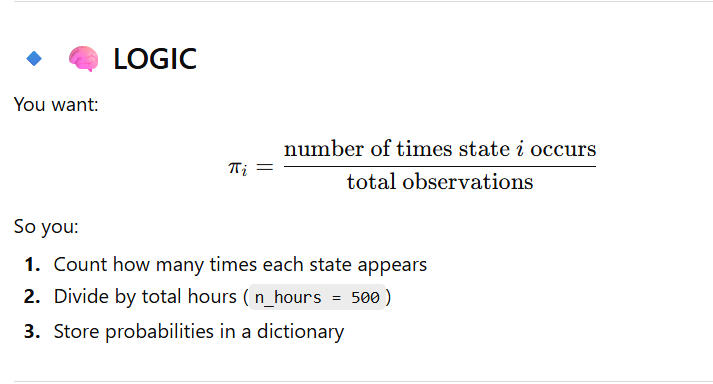

In [ ]:
df["label"].value_counts()

,count
label,
Non-Congestion,307
Congestion,193


In [ ]:
state_counts = df["label"].value_counts()

pi = {
    "Congestion": state_counts["Congestion"] / n_hours,
    "Non-Congestion": state_counts["Non-Congestion"] / n_hours
}

print("Initial probabilities:")
print(pi)


Initial probabilities:
{'Congestion': np.float64(0.386), 'Non-Congestion': np.float64(0.614)}


Transition Probbailities are calculated using Exponential Distribution.

Probability of Congested state to become non congested= e^-𝜆t

where 𝜆 is mean time for the congested state to become non-congested.

Probability of congested state to become congested= 1-e^-𝜆t


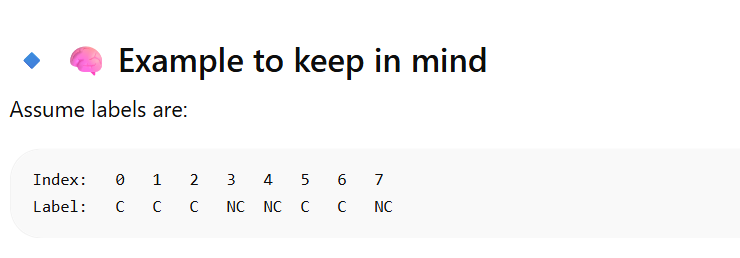

In [ ]:
ind=0
ind_congestion=[]
for each in df['label']:
  if each=='Congestion':
    ind_congestion.append(ind)
  ind=ind+1
cong_to_no_cong=[]
for each in ind_congestion:
  c=0
  i=each
  while(df.iloc[i]['label']!='Non-Congestion' and i!=len(df)-1):
    c=c+1
    i=i+1
  cong_to_no_cong.append(c)
print(np.mean(cong_to_no_cong))

ind=0
ind_non_congestion=[]
for each in df['label']:
  if each=='Non-Congestion':
    ind_non_congestion.append(ind)
  ind=ind+1
no_cong_to_cong=[]
for each in ind_non_congestion:
  c=0
  i=each
  while(df.iloc[i]['label']!='Congestion' and i!=len(df)-1):
    c=c+1
    i=i+1
  no_cong_to_cong.append(c)
print(np.mean(no_cong_to_cong))

mean_congestion_time = np.mean(cong_to_no_cong)     # hours
mean_freeflow_time = np.mean(no_cong_to_cong)       # hours

lambda_c = 1 / mean_congestion_time
lambda_nc = 1 / mean_freeflow_time

dt = 1  # 1 hour sampling

P_C_to_NC = np.exp(-lambda_c * dt)
P_NC_to_C = np.exp(-lambda_nc * dt)

A = np.array([
    [1 - P_C_to_NC, P_C_to_NC],
    [P_NC_to_C, 1 - P_NC_to_C]
])

print("\nTransition matrix:")
print(A)


1.6476683937823835
2.501628664495114

Transition matrix:
[[0.45497207 0.54502793]
 [0.67049463 0.32950537]]


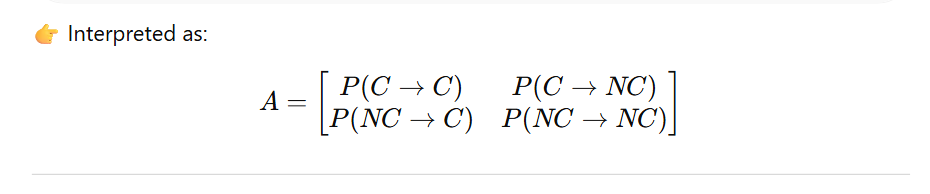

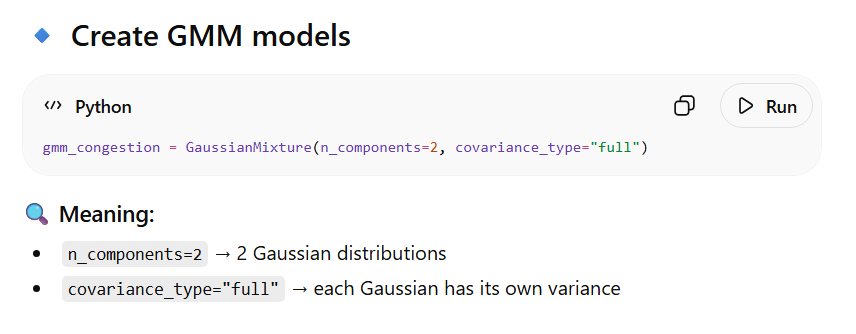

We are modelling the observation probabilities using Gaussian Mixture Models where we are taking 2 most prevalent components for each of the events

In [ ]:
X_c = df[df.label == "Congestion"]["vehicles_per_hour"].values.reshape(-1, 1)
X_nc = df[df.label == "Non-Congestion"]["vehicles_per_hour"].values.reshape(-1, 1)

gmm_congestion = GaussianMixture(n_components=2, covariance_type="full")
gmm_non_congestion = GaussianMixture(n_components=2, covariance_type="full")

gmm_congestion.fit(X_c)
gmm_non_congestion.fit(X_nc)

GaussianMixture(n_components=2)

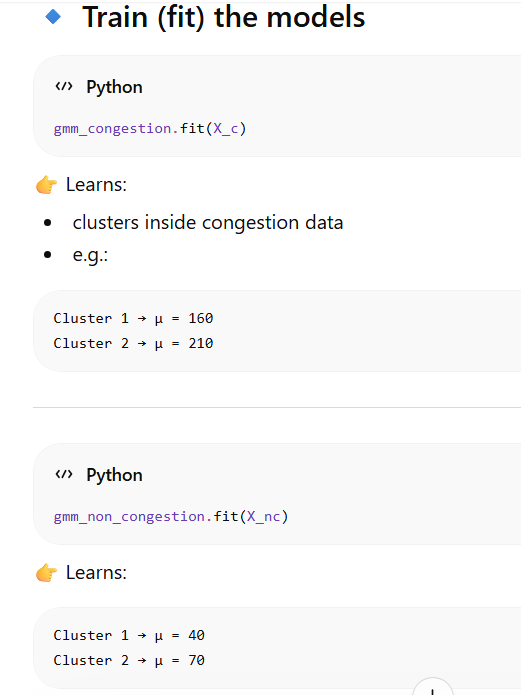

GMM expects:

(n_samples, n_features)

So:

150 → [[150]]

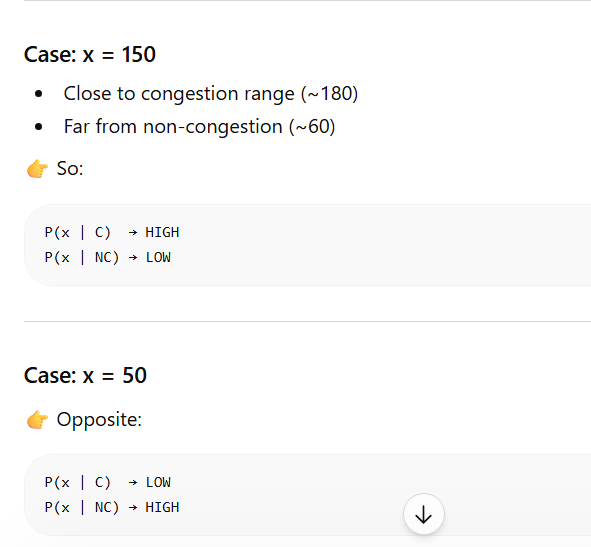

In [ ]:
def emission_probability(x):
    x = np.array([[x]])

    p_c = np.exp(gmm_congestion.score_samples(x))[0]
    #Compute probability for Congestion
    p_nc = np.exp(gmm_non_congestion.score_samples(x))[0]

    return p_c, p_nc


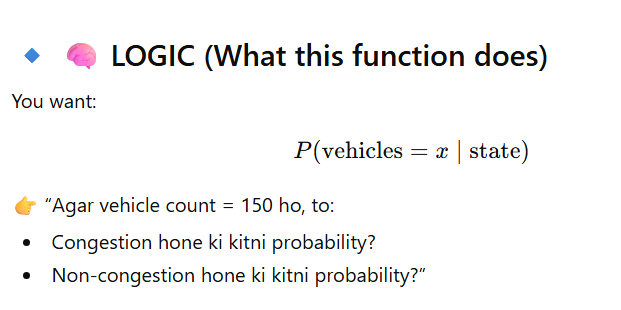

In [ ]:
vehicle_count = 150

p_c, p_nc = emission_probability(vehicle_count)

print("Vehicles/hour:", vehicle_count)
print("P(observation |Congestion ):", p_c)
print("P(observation | Non-Congestion):", p_nc)


Vehicles/hour: 150
P(observation |Congestion ): 0.009338949992972873
P(observation | Non-Congestion): 7.134007744131812e-12


Assignment: Calculate the P(150,200,100|C,C,NC) i.e. probability of congestion in the first hour, congestion in the second hour, non congestion in the third hour given thr number of vehicles passing through crossing are 150, 200, 100 for the consecutive three hours.

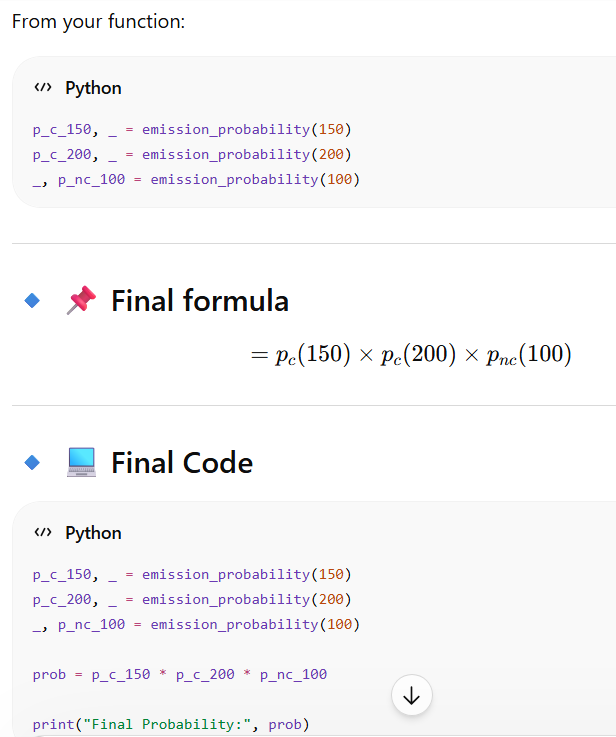